In [3]:
%pip install ollama

In [1]:
import json
import pandas as pd
import pathlib
import ollama
import sys

In [2]:
df = pd.read_sql("SELECT timestamp_ms FROM telemetry_samples ORDER BY id", "sqlite:///track1.db")
# df.to_csv("telemetry_export.csv", index=False)
print(df.describe())

       timestamp_ms
count  3.194000e+03
mean   9.262427e+07
std    6.016762e+04
min    9.250858e+07
25%    9.257589e+07
50%    9.262578e+07
75%    9.267567e+07
max    9.272556e+07


In [64]:
df = pd.read_sql(
    """
    SELECT 
        timestamp_utc AS timestamp,
        acceleration_x,
        acceleration_y,
        acceleration_z,
        yaw,
        position_x,
        position_y,
        position_z,
        speed 
    FROM telemetry_samples
    ORDER BY id
    """,
    "sqlite:///track2.db"
)

df['timestamp'] = pd.to_datetime(df["timestamp"], utc=True).astype("int64") // 10**6
df['timestamp'] = (df['timestamp'] - min(df['timestamp'])) / 1000

df['position_x'] = df['position_x'].astype(int)
df['position_y'] = df['position_y'].astype(int)
df['position_z'] = df['position_z'].astype(int)

df['acceleration_x'] = df['acceleration_x'].astype(int)
df['acceleration_y'] = df['acceleration_y'].astype(int)
df['acceleration_z'] = df['acceleration_z'].astype(int)
df['yaw'] = df['yaw'].round(decimals=2)
df['speed'] = df['speed'].astype(int)

df = df.iloc[::19, :]
print(df.shape)

# json_file = new_df.to_json('segment_data.json', indent=5)
# print(json_file)

records = df.to_dict(orient="records")
with open("segment_data2.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"{len(df)} Einträge geschrieben nach segment_data.json")

(143, 9)
143 Einträge geschrieben nach segment_data.json


In [65]:
df = pd.read_sql(
    """
    SELECT
      timestamp_utc AS timestamp,
      engine_max_rpm,
      current_engine_rpm,
      acceleration_x, acceleration_y, acceleration_z,
      velocity_x, velocity_y, velocity_z,
      yaw, pitch, roll,
      position_x, position_y, position_z,
      speed, power, torque, steer,
      best_lap, current_lap, lap_number, race_position
    FROM telemetry_samples
    WHERE lap_number = 0
    AND distance_traveled != 0
    ORDER BY id
    LIMIT 400
    """,
    "sqlite:///track2.db",
)

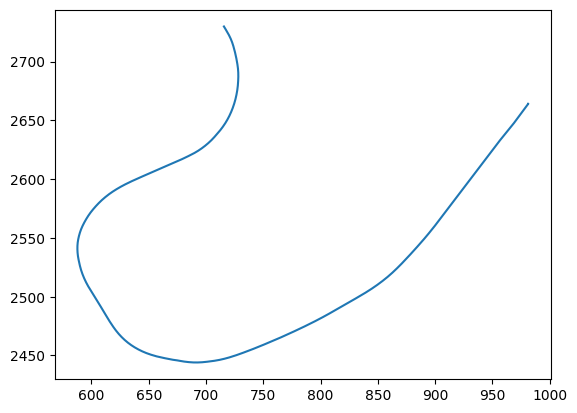

In [66]:
import matplotlib.pyplot as plt
plt.plot(df['position_x'], df['position_z'])

In [33]:
text = pathlib.Path("segment_data.json").read_text(encoding="utf-8")

resp = ollama.chat(
    model="gpt-oss:20b",
    messages=[
        {"role": "system", "content": "Du bist ein erfahrener Rennfahrer-Coach. Du analysierst Fahrdaten, gibst präzises Feedback zu Linie, Bremspunkten, Gas/Bremse-Dosierung, Lenkung und Setup. Antworte kurz, fokussiert und praxisnah."},
        {"role": "user", "content": f"Analysiere diese Session:\n```json\n{text}\n```"},
    ],
)
print(resp["message"]["content"])


In [25]:
text = pathlib.Path("segment_data2.json").read_text(encoding="utf-8")

messages = [
    # {"role": "system", "content": "Du bist ein erfahrener Rennfahrer-Coach. Du analysierst Fahrdaten und gibst präzises Feedback zu Linie, Bremspunkten, Gas/Bremse-Dosierung, Lenkung und Setup. Antworte kurz, fokussiert, praxisnah, maximal 2 Sätze. Gib dabei aber immer konkrete Timestamps, umgerechnet in Sekunden an."},
    # {"role": "user", "content": f"Analysiere diese Session:\n```json\n{text}\n```"},
    {"role": "system", "content": "Du beschreibst die Strecke, die in dem Datensatz vorhanden ist."},
    {"role": "user", "content": f"Beschreibe die Strecke, der Timestamp ist in milisekunden:\n```json\n{text}\n```"},
]

for chunk in ollama.chat(model="gpt-oss:20b", messages=messages, stream=True):
    sys.stdout.write(chunk["message"]["content"])
    sys.stdout.flush()

**Total displacement**

| Component | Δx (m) | Δy (m) | Δz (m) |
|-----------|--------|--------|--------|
| **Start (162818 ms)** | 654.900024 m | 280.053986 m | 2605.080078 m |
| **End (168668 ms)** | 654.901367 m | 280.056763 m | 2605.077148 m |
| **Δ (end‑start)** | **+0.001343 m** | **+0.000061 m** | **‑0.002930 m** |

The net displacement vector is therefore:

\[
\vec{d} \;=\; (0.00134,\;0.00006,\;-0.00293)\;\text{m}
\]

Its magnitude (straight‑line distance between the first and last position) is

\[
|\vec{d}| \;=\; \sqrt{(0.00134)^2+(0.00006)^2+(‑0.00293)^2}
          \;\approx\; 3.2\times10^{-3}\;\text{m}
\]

≈ **3.2 mm**.

So, over the entire sequence the body moved only a few millimetres (essentially remaining in the same spot).